### Imports

In [6]:
import json
import warnings
from pathlib import Path

import optuna
import torch
import torch.nn as nn

from src.datasets.audio_dataset import AudioDataset
from src.engine import train_one_epoch_cnn, validate_cnn, get_split_dataloaders, benchmark_cnn
from src.models.cnn import CNN
from src.preprocessing import get_cnn_pipeline
from src.utils import CONFIG
from src.utils import plot_training_history, run_sweep

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [7]:
MODEL_NAME = CNN.NAME

INPUT_DIR = Path('../../data/audio-mnist')
HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{MODEL_NAME}.json')
MODEL_PATH = Path(f'../../models/{MODEL_NAME}.pth')

### Device

In [8]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [9]:
def objective(trial) -> float:
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    dataset = AudioDataset(INPUT_DIR, get_cnn_pipeline(CONFIG.audiomnist))
    train_dataloader, val_dataloader, _ = get_split_dataloaders(dataset)

    model = CNN().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    val_acc = 0.0
    for epoch in range(CONFIG.hyperparameter_tuning.epochs):
        train_one_epoch_cnn(device, model, criterion, optimiser, train_dataloader)
        val_loss, val_acc = validate_cnn(device, model, criterion, val_dataloader)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

if CONFIG.hyperparameter_tuning.should_run:
    run_sweep(objective, HYPERPARAMETERS_PATH)

### Training

Hyperparameters used: {'lr': 0.007039879588220245}

Training cnn...
[Epoch 1/50]


Validating: 100%|██████████| 12/12 [00:07<00:00,  1.56batches/s]


Train Loss: 0.29 | Train Accuracy: 92.32% | Val Loss: 0.08 | Val Accuracy: 98.03%

[Epoch 2/50]


Validating: 100%|██████████| 12/12 [00:01<00:00,  6.79batches/s]


Train Loss: 0.03 | Train Accuracy: 99.28% | Val Loss: 0.05 | Val Accuracy: 98.70%

[Epoch 3/50]


...

Train Loss: 0.00 | Train Accuracy: 100.00% | Val Loss: 0.02 | Val Accuracy: 99.77%

[Epoch 20/50]


Validating: 100%|██████████| 12/12 [00:01<00:00,  6.81batches/s]

Stopping early at epoch 20 (no improvement for 5 epochs)
Best model had an accuracy of 99.77%.
Running final test...



Testing: 100%|██████████| 12/12 [00:02<00:00,  5.92batches/s]


Test Accuracy: 99.87% | Total MACs: 694778


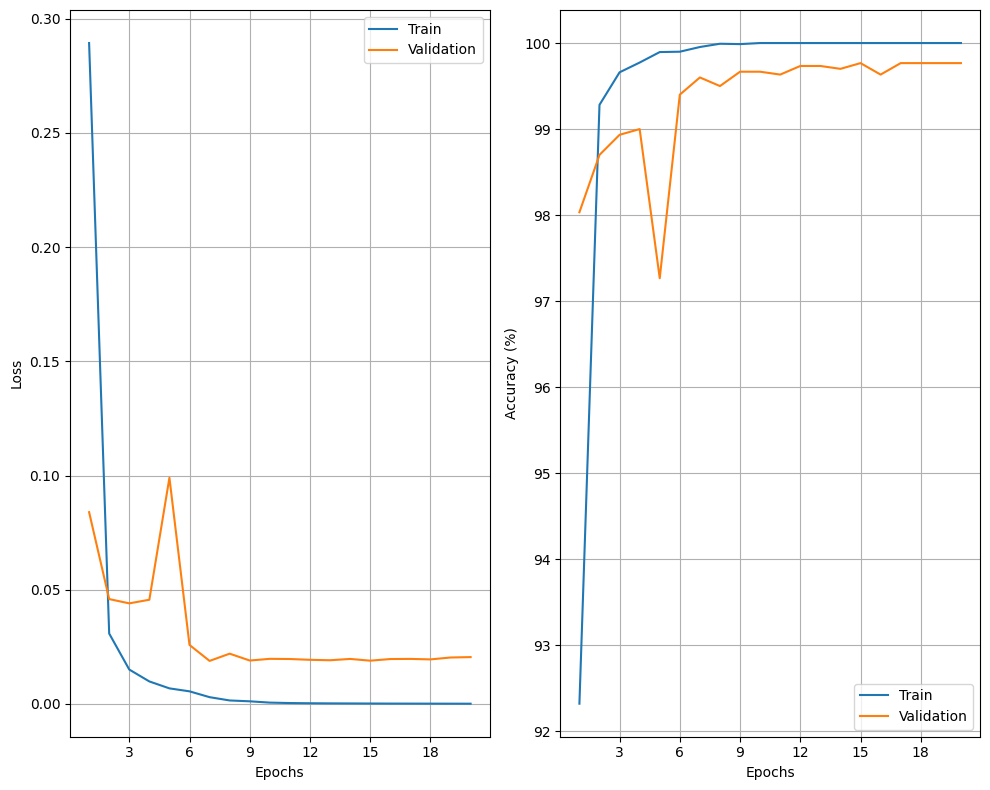

In [10]:
if __name__ == '__main__':
    dataset = AudioDataset(INPUT_DIR, get_cnn_pipeline(CONFIG.audiomnist))
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Load hyperparameters
    hyperparameters = json.load(open(HYPERPARAMETERS_PATH, 'r'))
    print(f'Hyperparameters used: {hyperparameters}')
    print()

    model = CNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters['lr'])
    criterion = nn.CrossEntropyLoss()

    print(f'Training {model.NAME}...')
    best_acc = 0.0
    epochs_without_improvement = 0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(CONFIG.epochs):
        print(f'[Epoch {epoch + 1}/{CONFIG.epochs}]')

        train_loss, train_acc = train_one_epoch_cnn(device, model, criterion, optimizer, train_dataloader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = validate_cnn(device, model, criterion, val_dataloader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement == CONFIG.patience:
            print(f'Stopping early at epoch {epoch + 1} (no improvement for {CONFIG.patience} epochs)')
            break

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_acc:.2f}%')
        print()

    print(f'Best model had an accuracy of {best_acc:.2f}%.')
    print(f'Running final test...')
    model.load_state_dict(torch.load(MODEL_PATH))

    test_accuracy, macs = benchmark_cnn(device, model, test_dataloader)
    print(f'Test Accuracy: {test_accuracy:.2f}% | Total MACs: {macs}')

    plot_training_history(train_losses, train_accs, val_losses, val_accs)